In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# Load the MNIST handwritten digits dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


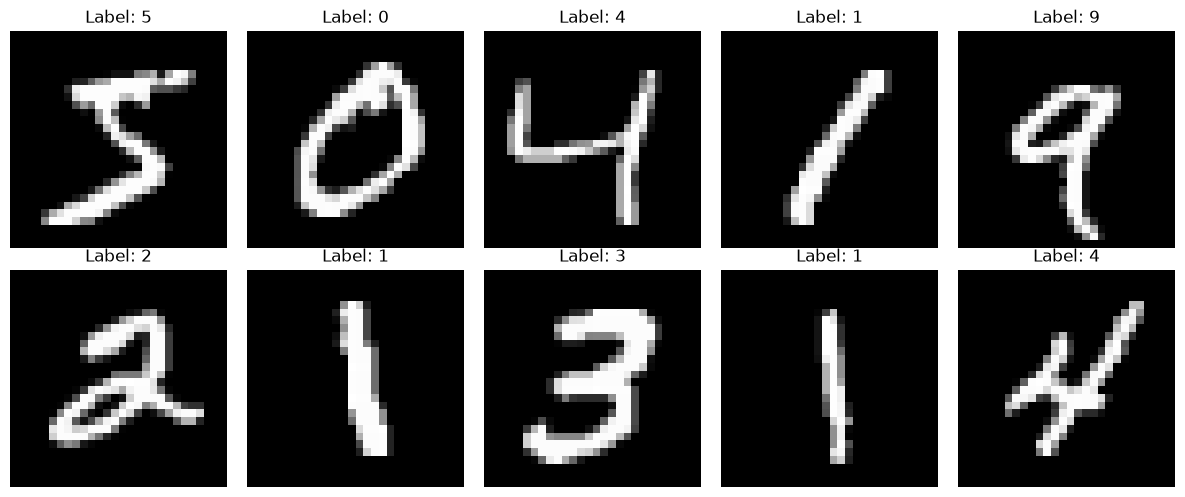

In [3]:
# Display sample images from the training dataset
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# Inspect pixel value range
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())
print("Training data type:", x_train.dtype)

Minimum pixel value: 0
Maximum pixel value: 255
Training data type: uint8


In [5]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum normalized value:", x_train.min())
print("Maximum normalized value:", x_train.max())
print("Training data type:", x_train.dtype)

Minimum normalized value: 0.0
Maximum normalized value: 1.0
Training data type: float32


In [6]:
# Add the grayscale channel dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training images after reshape:", x_train.shape)
print("Test images after reshape:", x_test.shape)

Training images after reshape: (60000, 28, 28, 1)
Test images after reshape: (10000, 28, 28, 1)


In [7]:
# Build the convolutional neural network
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(
        units=128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        units=10,
        activation="softmax"
    )
])

print("CNN model created successfully")

CNN model created successfully


In [8]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")

Model compiled successfully


In [9]:
# Display the model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the CNN model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.9363 - loss: 0.2086 - val_accuracy: 0.9843 - val_loss: 0.0535
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9787 - loss: 0.0676 - val_accuracy: 0.9880 - val_loss: 0.0375
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9858 - loss: 0.0472 - val_accuracy: 0.9878 - val_loss: 0.0383
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9894 - loss: 0.0363 - val_accuracy: 0.9908 - val_loss: 0.0323
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9907 - loss: 0.0295 - val_accuracy: 0.9917 - val_loss: 0.0298


In [11]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy percentage: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9902 - loss: 0.0269
Test loss: 0.0269
Test accuracy: 0.9902
Test accuracy percentage: 99.02%


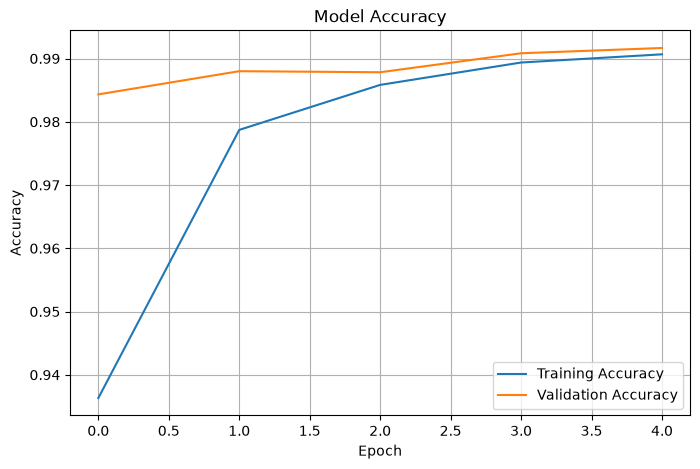

In [12]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

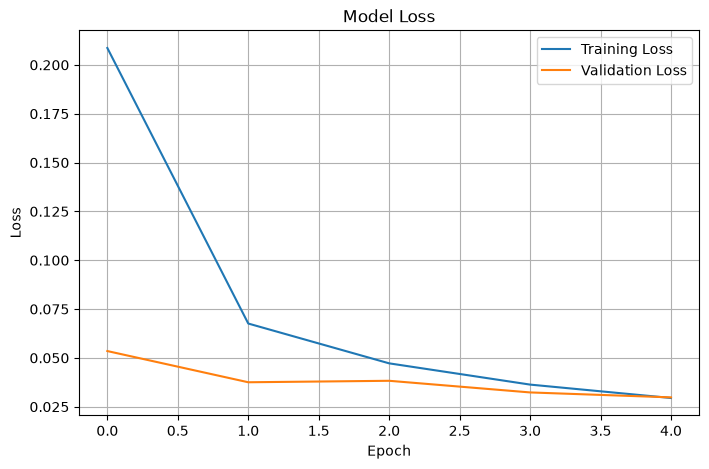

In [13]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Generate predictions for the test dataset
predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)

print("Predictions shape:", predictions.shape)
print("First 10 predicted classes:", predicted_classes[:10])
print("First 10 actual classes:", y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predictions shape: (10000, 10)
First 10 predicted classes: [7 2 1 0 4 1 4 9 5 9]
First 10 actual classes: [7 2 1 0 4 1 4 9 5 9]


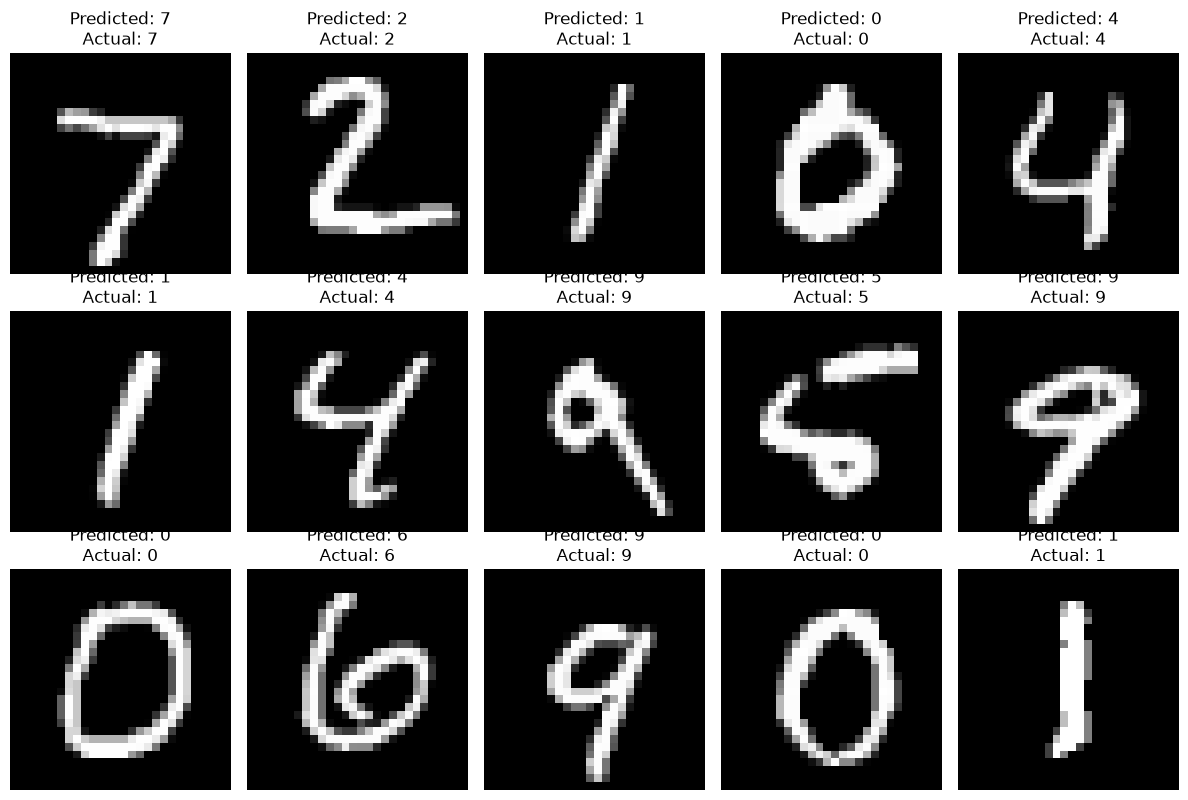

In [15]:
# Display sample predictions
plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(x_test[i].squeeze(), cmap="gray")

    predicted = predicted_classes[i]
    actual = y_test[i]

    plt.title(
        f"Predicted: {predicted}\nActual: {actual}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Generate the classification report
report = classification_report(
    y_test,
    predicted_classes
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       1.00      0.98      0.99       958
           7       0.98      0.99      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [17]:
# Save the trained model
model.save("../models/digit_recognition_cnn.keras")

print("Model saved successfully")

Model saved successfully
